In [ ]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import lif_utils as lu
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
snn_speed6_all_directions_thr100 = test_downstream_snn_constant_speed_all_directions(
    speed=6,
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

snn_speed6_all_directions_thr100

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,final_membrane_max,correct
0,right,6,right,6,6.0,7.0,0.978761,True
1,left,6,left,6,6.0,7.0,0.978761,True
2,down,6,down,6,34.0,67.0,0.978761,True
3,up,6,up,6,31.0,65.0,0.978761,True


In [10]:
SHAPE_TEMPLATES = lu.make_toy_2d_shape_templates()

INTENSITY = 1.0
BLUR_KERNEL_LENGTH = 9
BLUR_SIGMA_ALONG = 1.3
BLUR_SIGMA_ACROSS = 0.1
BLUR_GAIN = 1.2
LIF_BETA = 0.9
LIF_THRESHOLD = 0.75

In [11]:
ORACLE_SPEED_CANVAS_HEIGHT = 128
ORACLE_SPEED_CANVAS_WIDTH = 128
ORACLE_SPEED_T_PLOT = 6
ORACLE_SPEED_BUFFER_SIZE = 4

TRUE_SPEEDS_TO_TEST = list(range(1, 21))

CANDIDATE_SPEED_VALUES = list(range(0, 25))

CONSTANT_SPEED_HISTORY_CANDIDATES = list(
    itertools.product(CANDIDATE_SPEED_VALUES, repeat=3)
)

len(CONSTANT_SPEED_HISTORY_CANDIDATES)

15625

In [12]:
ORACLE_DIRECTION_LIBRARY_4 = {
    "right": {
        "direction_y": 0,
        "direction_x": 1,
        "start_top": 60,
        "start_left": 20,
    },
    "left": {
        "direction_y": 0,
        "direction_x": -1,
        "start_top": 60,
        "start_left": 103,
    },
    "down": {
        "direction_y": 1,
        "direction_x": 0,
        "start_top": 20,
        "start_left": 60,
    },
    "up": {
        "direction_y": -1,
        "direction_x": 0,
        "start_top": 103,
        "start_left": 60,
    },
}

In [13]:
def make_constant_speed_condition(direction_params, speed):
    return {
        "direction_y": direction_params["direction_y"],
        "direction_x": direction_params["direction_x"],
        "speed_sequence": [speed, speed, speed, speed, speed, speed],
        "start_top": direction_params["start_top"],
        "start_left": direction_params["start_left"],
    }

In [15]:
def make_constant_speed_condition(direction_params, speed):
    return {
        "direction_y": direction_params["direction_y"],
        "direction_x": direction_params["direction_x"],
        "speed_sequence": [speed, speed, speed, speed, speed, speed],
        "start_top": direction_params["start_top"],
        "start_left": direction_params["start_left"],
    }


def make_variable_speed_same_direction_sequence(condition):
    velocity_sequence = []

    for speed in condition["speed_sequence"]:
        velocity_sequence.append((
            condition["direction_y"] * speed,
            condition["direction_x"] * speed,
        ))

    return velocity_sequence


def make_variable_velocity_2d_shape(
    shape,
    canvas_height,
    canvas_width,
    start_top,
    start_left,
    velocity_sequence,
    intensity=1.0,
):
    steps = len(velocity_sequence) + 1

    frames = torch.zeros(
        (steps, canvas_height, canvas_width),
        dtype=shape.dtype,
        device=shape.device,
    )

    origins = []

    top = float(start_top)
    left = float(start_left)

    shape_h, shape_w = shape.shape

    for t in range(steps):
        top_i = int(round(top))
        left_i = int(round(left))

        origins.append((top_i, left_i))

        row_start = max(top_i, 0)
        row_end = min(top_i + shape_h, canvas_height)
        col_start = max(left_i, 0)
        col_end = min(left_i + shape_w, canvas_width)

        shape_row_start = row_start - top_i
        shape_row_end = shape_row_start + (row_end - row_start)
        shape_col_start = col_start - left_i
        shape_col_end = shape_col_start + (col_end - col_start)

        if row_start < row_end and col_start < col_end:
            frames[t, row_start:row_end, col_start:col_end] = (
                intensity
                * shape[shape_row_start:shape_row_end, shape_col_start:shape_col_end]
            )

        if t < len(velocity_sequence):
            velocity_y, velocity_x = velocity_sequence[t]
            top += velocity_y
            left += velocity_x

    return frames, origins


def true_lag_shifts_from_origins(
    origins,
    t_plot,
    buffer_size=4,
):
    current_top, current_left = origins[t_plot]

    lag_shifts = {}

    for lag in range(buffer_size):
        source_t = t_plot - lag
        source_top, source_left = origins[source_t]

        lag_shifts[lag] = (
            current_top - source_top,
            current_left - source_left,
        )

    return lag_shifts


def compensate_frame_at_t_with_lag_shifts(
    frames,
    t_plot,
    lag_shifts,
    buffer_size=4,
):
    acc = torch.zeros_like(frames[t_plot])

    for lag in range(buffer_size):
        source_t = t_plot - lag

        if source_t < 0:
            continue

        shift_y, shift_x = lag_shifts[lag]

        shifted = lu.shift_2d_frame(
            frames[source_t],
            shift_y=shift_y,
            shift_x=shift_x,
        )

        acc += shifted

    return acc


def lag_shifts_from_recent_speed_history(
    recent_speeds,
    direction_y,
    direction_x,
):
    s_oldest, s_middle, s_newest = recent_speeds

    return {
        0: (0, 0),
        1: (
            direction_y * s_newest,
            direction_x * s_newest,
        ),
        2: (
            direction_y * (s_middle + s_newest),
            direction_x * (s_middle + s_newest),
        ),
        3: (
            direction_y * (s_oldest + s_middle + s_newest),
            direction_x * (s_oldest + s_middle + s_newest),
        ),
    }

In [16]:
def run_varying_speed_metric_validation_experiment(
    shape_name,
    condition_name,
    shape_templates,
    motion_conditions,
    recent_speed_history_candidates,
    canvas_height=128,
    canvas_width=128,
    t_plot=6,
    intensity=1.0,
    blur_kernel_length=9,
    blur_sigma_along=1.3,
    blur_sigma_across=0.1,
    blur_gain=1.2,
    lif_beta=0.9,
    lif_threshold=0.75,
    buffer_size=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    shape = shape_templates[shape_name]
    condition = motion_conditions[condition_name]

    velocity_sequence = make_variable_speed_same_direction_sequence(condition)

    frames, origins = make_variable_velocity_2d_shape(
        shape=shape,
        canvas_height=canvas_height,
        canvas_width=canvas_width,
        start_top=condition["start_top"],
        start_left=condition["start_left"],
        velocity_sequence=velocity_sequence,
        intensity=intensity,
    )

    mean_velocity_y = sum(vy for vy, vx in velocity_sequence) / len(velocity_sequence)
    mean_velocity_x = sum(vx for vy, vx in velocity_sequence) / len(velocity_sequence)

    input_current = lu.apply_directional_blur_to_frames(
        frames,
        velocity_y=mean_velocity_y,
        velocity_x=mean_velocity_x,
        kernel_length=blur_kernel_length,
        sigma_along=blur_sigma_along,
        sigma_across=blur_sigma_across,
        gain=blur_gain,
    )

    spikes, membrane = lu.run_lif_2d_layer(
        input_current,
        beta=lif_beta,
        threshold=lif_threshold,
    )

    true_lag_shifts = true_lag_shifts_from_origins(
        origins,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    target = compensate_frame_at_t_with_lag_shifts(
        input_current,
        t_plot=t_plot,
        lag_shifts=true_lag_shifts,
        buffer_size=buffer_size,
    )

    target_mask = lu.make_binary_target_mask(
        target,
        threshold_fraction=threshold_fraction,
    )

    true_recent_speeds = tuple(condition["speed_sequence"][-(buffer_size - 1):])

    rows = []

    for recent_speeds in recent_speed_history_candidates:
        candidate_lag_shifts = lag_shifts_from_recent_speed_history(
            recent_speeds,
            direction_y=condition["direction_y"],
            direction_x=condition["direction_x"],
        )

        candidate_frame = compensate_frame_at_t_with_lag_shifts(
            membrane,
            t_plot=t_plot,
            lag_shifts=candidate_lag_shifts,
            buffer_size=buffer_size,
        )

        candidate_frame = torch.clamp(candidate_frame, min=0)

        target_energy = (candidate_frame * target_mask).sum().item()
        residual_energy = (candidate_frame * (1.0 - target_mask)).sum().item()
        score = target_energy - residual_penalty * residual_energy

        rows.append({
            "shape": shape_name,
            "condition": condition_name,
            "candidate_recent_speeds": recent_speeds,
            "true_recent_speeds": true_recent_speeds,
            "target_energy": target_energy,
            "residual_energy": residual_energy,
            "score": score,
            "correct": recent_speeds == true_recent_speeds,
        })

    scores = pd.DataFrame(rows).sort_values("score", ascending=False)

    return {
        "frames": frames,
        "input_current": input_current,
        "spikes": spikes,
        "membrane": membrane,
        "origins": origins,
        "true_lag_shifts": true_lag_shifts,
        "target": target,
        "scores": scores,
    }

In [17]:
def run_oracle_constant_speed_metric_test_one_case(
    speed,
    direction_name,
    shape_name="seven",
    shape_templates=SHAPE_TEMPLATES,
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    condition = make_constant_speed_condition(
        ORACLE_DIRECTION_LIBRARY_4[direction_name],
        speed,
    )

    condition_name = f"{direction_name}_constant_{speed}"

    motion_conditions = {
        condition_name: condition
    }

    result = run_varying_speed_metric_validation_experiment(
        shape_name=shape_name,
        condition_name=condition_name,
        shape_templates=shape_templates,
        motion_conditions=motion_conditions,
        recent_speed_history_candidates=CONSTANT_SPEED_HISTORY_CANDIDATES,
        canvas_height=ORACLE_SPEED_CANVAS_HEIGHT,
        canvas_width=ORACLE_SPEED_CANVAS_WIDTH,
        t_plot=ORACLE_SPEED_T_PLOT,
        intensity=INTENSITY,
        blur_kernel_length=BLUR_KERNEL_LENGTH,
        blur_sigma_along=BLUR_SIGMA_ALONG,
        blur_sigma_across=BLUR_SIGMA_ACROSS,
        blur_gain=BLUR_GAIN,
        lif_beta=LIF_BETA,
        lif_threshold=LIF_THRESHOLD,
        buffer_size=ORACLE_SPEED_BUFFER_SIZE,
        threshold_fraction=threshold_fraction,
        residual_penalty=residual_penalty,
    )

    scores = result["scores"].reset_index(drop=True)
    best = scores.iloc[0]

    true_recent_speeds = (speed, speed, speed)

    true_rows = scores[
        scores["candidate_recent_speeds"] == true_recent_speeds
    ]

    true_rank = int(true_rows.index[0] + 1)
    true_score = float(true_rows.iloc[0]["score"])

    return {
        "speed": speed,
        "direction": direction_name,
        "true_recent_speeds": true_recent_speeds,
        "best_candidate_recent_speeds": best["candidate_recent_speeds"],
        "best_score": float(best["score"]),
        "true_score": true_score,
        "score_gap_best_minus_true": float(best["score"] - true_score),
        "true_rank": true_rank,
        "correct": best["candidate_recent_speeds"] == true_recent_speeds,
        "result": result,
    }

In [18]:
test_out = run_oracle_constant_speed_metric_test_one_case(
    speed=4,
    direction_name="right",
)

test_out["best_candidate_recent_speeds"], test_out["true_recent_speeds"], test_out["true_rank"]

((4, 4, 8), (4, 4, 4), 584)

In [19]:
test_out["result"]["scores"].head(20)

,shape,condition,candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
2608,seven,right_constant_4,"(4, 4, 8)","(4, 4, 4)",18.548866,104.380035,13.329865,False
2560,seven,right_constant_4,"(4, 2, 10)","(4, 4, 4)",18.348743,104.580154,13.119736,False
1408,seven,right_constant_4,"(2, 6, 8)","(4, 4, 4)",18.348743,104.580154,13.119736,False
3858,seven,right_constant_4,"(6, 4, 8)","(4, 4, 4)",18.348743,104.580154,13.119736,False
2656,seven,right_constant_4,"(4, 6, 6)","(4, 4, 4)",18.200857,104.728043,12.964455,False
3808,seven,right_constant_4,"(6, 2, 8)","(4, 4, 4)",18.200855,104.728043,12.964453,False
1358,seven,right_constant_4,"(2, 4, 8)","(4, 4, 4)",18.200855,104.728043,12.964453,False
3208,seven,right_constant_4,"(5, 3, 8)","(4, 4, 4)",18.165878,104.763016,12.927728,False
1983,seven,right_constant_4,"(3, 4, 8)","(4, 4, 4)",18.165878,104.763023,12.927727,False
2632,seven,right_constant_4,"(4, 5, 7)","(4, 4, 4)",18.165876,104.763016,12.927726,False


In [20]:
def run_oracle_constant_speed_threshold_sweep(
    speeds=(4, 5, 6, 7, 8),
    directions=("right", "left", "down", "up"),
    shape_name="seven",
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    rows = []
    full_results = {}

    for direction_name in directions:
        full_results[direction_name] = {}

        for speed in speeds:
            out = run_oracle_constant_speed_metric_test_one_case(
                speed=speed,
                direction_name=direction_name,
                shape_name=shape_name,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
            )

            full_results[direction_name][speed] = out["result"]

            rows.append({
                "shape": shape_name,
                "direction": direction_name,
                "speed": speed,
                "true_recent_speeds": out["true_recent_speeds"],
                "best_candidate_recent_speeds": out["best_candidate_recent_speeds"],
                "true_rank": out["true_rank"],
                "best_score": out["best_score"],
                "true_score": out["true_score"],
                "score_gap_best_minus_true": out["score_gap_best_minus_true"],
                "correct": out["correct"],
            })

    return pd.DataFrame(rows), full_results

In [48]:
oracle_speed_threshold_summary, oracle_speed_threshold_results = (
    run_oracle_constant_speed_threshold_sweep(
        speeds=(2,3,4,5,6),
        directions=("right", "left", "down", "up"),
        shape_name="seven",
        threshold_fraction=0.25,
        residual_penalty=0.05,
    )
)

oracle_speed_threshold_summary

,shape,direction,speed,true_recent_speeds,best_candidate_recent_speeds,true_rank,best_score,true_score,score_gap_best_minus_true,correct
0,seven,right,2,"(2, 2, 2)","(2, 2, 4)",106,20.202916,18.253560,1.949356,False
1,seven,right,3,"(3, 3, 3)","(3, 3, 5)",87,13.716912,12.839872,0.877039,False
2,seven,right,4,"(4, 4, 4)","(4, 4, 8)",584,13.329865,11.701487,1.628378,False
3,seven,right,5,"(5, 5, 5)","(5, 5, 10)",46,11.115237,10.390101,0.725137,False
4,seven,right,6,"(6, 6, 6)","(6, 6, 6)",1,7.670690,7.670690,0.000000,True
5,seven,left,2,"(2, 2, 2)","(2, 2, 4)",106,20.202916,18.253559,1.949357,False
6,seven,left,3,"(3, 3, 3)","(3, 3, 5)",87,13.716910,12.839873,0.877037,False
7,seven,left,4,"(4, 4, 4)","(4, 4, 8)",584,13.329867,11.701484,1.628382,False
8,seven,left,5,"(5, 5, 5)","(5, 5, 10)",46,11.115237,10.390101,0.725136,False
9,seven,left,6,"(6, 6, 6)","(6, 6, 6)",1,7.670691,7.670691,0.000000,True


In [42]:
def visualize_oracle_speed4_case(
    direction_name="right",
    speed=4,
    threshold_fraction=0.25,
    t_plot=ORACLE_SPEED_T_PLOT,
    buffer_size=ORACLE_SPEED_BUFFER_SIZE,
):
    # Use existing sweep result if available; otherwise run this one case.
    try:
        result = oracle_speed_threshold_results[direction_name][speed]
        scores = result["scores"].reset_index(drop=True)
    except NameError:
        out = run_oracle_constant_speed_metric_test_one_case(
            speed=speed,
            direction_name=direction_name,
            threshold_fraction=threshold_fraction,
        )
        result = out["result"]
        scores = result["scores"].reset_index(drop=True)

    condition = make_constant_speed_condition(
        ORACLE_DIRECTION_LIBRARY_4[direction_name],
        speed,
    )

    best = scores.iloc[0]
    true_recent_speeds = (speed, speed, speed)
    best_recent_speeds = best["candidate_recent_speeds"]

    target = result["target"]
    target_mask = lu.make_binary_target_mask(
        target,
        threshold_fraction=threshold_fraction,
    )

    true_lag_shifts = lag_shifts_from_recent_speed_history(
        true_recent_speeds,
        direction_y=condition["direction_y"],
        direction_x=condition["direction_x"],
    )

    best_lag_shifts = lag_shifts_from_recent_speed_history(
        best_recent_speeds,
        direction_y=condition["direction_y"],
        direction_x=condition["direction_x"],
    )

    true_comp = compensate_frame_at_t_with_lag_shifts(
        result["membrane"],
        t_plot=t_plot,
        lag_shifts=true_lag_shifts,
        buffer_size=buffer_size,
    )
    true_comp = torch.clamp(true_comp, min=0)

    best_comp = compensate_frame_at_t_with_lag_shifts(
        result["membrane"],
        t_plot=t_plot,
        lag_shifts=best_lag_shifts,
        buffer_size=buffer_size,
    )
    best_comp = torch.clamp(best_comp, min=0)

    true_residual = true_comp * (1.0 - target_mask)
    best_residual = best_comp * (1.0 - target_mask)

    diff = best_comp - true_comp

    frame_times = list(range(t_plot - buffer_size + 1, t_plot + 1))

    vmax_input = max(result["input_current"][t].max().item() for t in frame_times)
    vmax_membrane = max(result["membrane"][t].max().item() for t in frame_times)
    vmax_comp = max(target.max().item(), true_comp.max().item(), best_comp.max().item())

    fig, axes = plt.subplots(4, 4, figsize=(16, 15))

    # Row 1: blurred input frames
    for col, t in enumerate(frame_times):
        axes[0, col].imshow(
            result["input_current"][t].detach().cpu(),
            cmap="magma",
            vmin=0,
            vmax=vmax_input,
        )
        axes[0, col].set_title(f"Blurred input t={t}")

    # Row 2: membrane frames
    for col, t in enumerate(frame_times):
        axes[1, col].imshow(
            result["membrane"][t].detach().cpu(),
            cmap="magma",
            vmin=0,
            vmax=vmax_membrane,
        )
        axes[1, col].set_title(f"Membrane t={t}")

    # Row 3: target and compensated frames
    axes[2, 0].imshow(target.detach().cpu(), cmap="magma", vmin=0, vmax=vmax_comp)
    axes[2, 0].set_title("Oracle target")

    axes[2, 1].imshow(target_mask.detach().cpu(), cmap="gray")
    axes[2, 1].set_title("Target mask")

    axes[2, 2].imshow(true_comp.detach().cpu(), cmap="magma", vmin=0, vmax=vmax_comp)
    axes[2, 2].set_title(f"True comp {true_recent_speeds}")

    axes[2, 3].imshow(best_comp.detach().cpu(), cmap="magma", vmin=0, vmax=vmax_comp)
    axes[2, 3].set_title(f"Best comp {best_recent_speeds}")

    # Row 4: residuals and difference
    axes[3, 0].imshow(true_residual.detach().cpu(), cmap="magma")
    axes[3, 0].set_title("True residual outside mask")

    axes[3, 1].imshow(best_residual.detach().cpu(), cmap="magma")
    axes[3, 1].set_title("Best residual outside mask")

    max_abs_diff = diff.abs().max().item()
    if max_abs_diff == 0:
        max_abs_diff = 1.0

    axes[3, 2].imshow(
        diff.detach().cpu(),
        cmap="bwr",
        vmin=-max_abs_diff,
        vmax=max_abs_diff,
    )
    axes[3, 2].set_title("Best - true")

    axes[3, 3].axis("off")
    axes[3, 3].text(
        0,
        0.98,
        f"Direction: {direction_name}\n"
        f"Speed: {speed}\n\n"
        f"True speeds: {true_recent_speeds}\n"
        f"Best speeds: {best_recent_speeds}\n\n"
        f"True lag shifts:\n{true_lag_shifts}\n\n"
        f"Best lag shifts:\n{best_lag_shifts}\n\n"
        f"Best score: {best['score']:.3f}",
        va="top",
        family="monospace",
        fontsize=10,
    )

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

    return {
        "result": result,
        "scores": scores,
        "true_recent_speeds": true_recent_speeds,
        "best_recent_speeds": best_recent_speeds,
        "true_lag_shifts": true_lag_shifts,
        "best_lag_shifts": best_lag_shifts,
    }

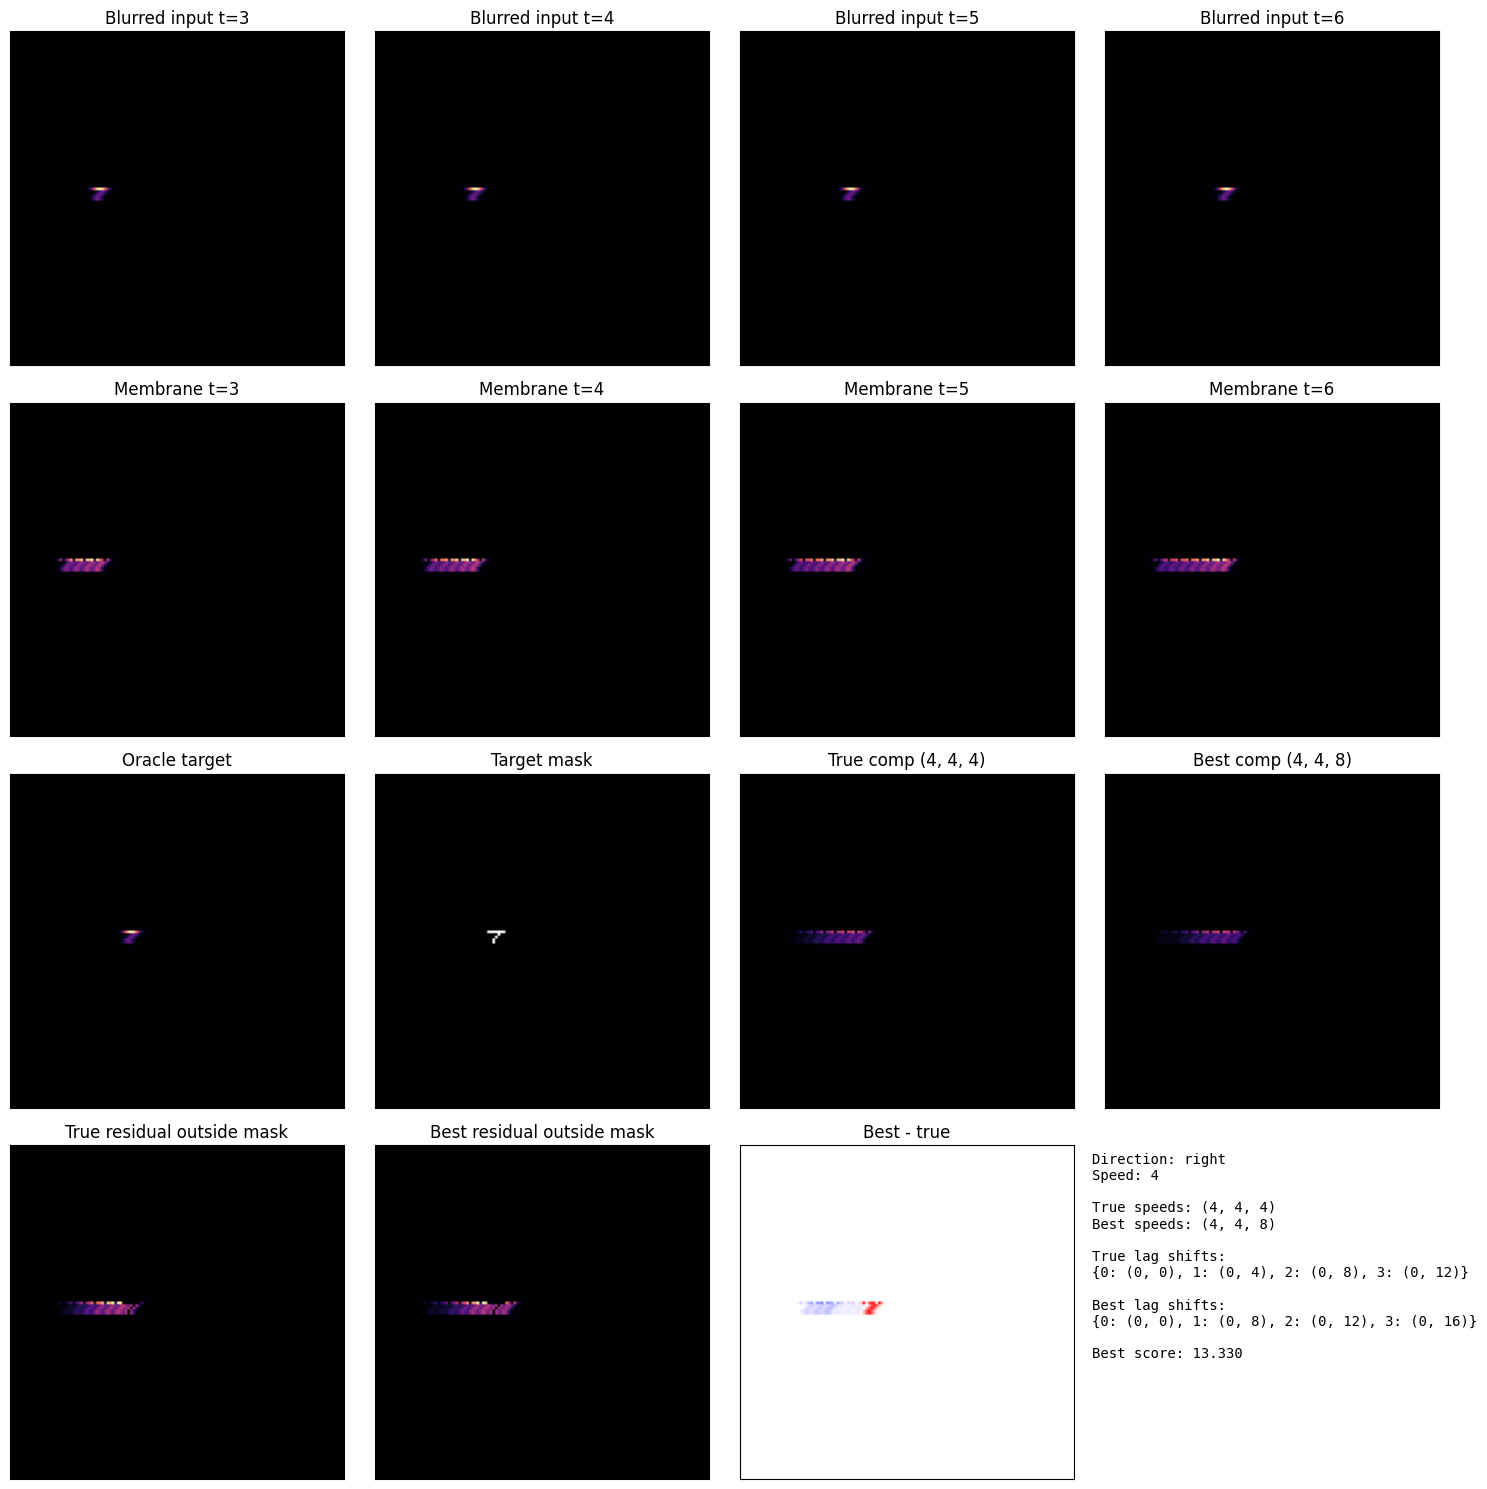

In [47]:
speed4_vis = visualize_oracle_speed4_case(
    direction_name="right",
    speed=4,
    threshold_fraction=0.25,
)

In [37]:
speed4_vis["scores"].head(20)[[
    "candidate_recent_speeds",
    "true_recent_speeds",
    "target_energy",
    "residual_energy",
    "score",
    "correct",
]]

,candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
0,"(4, 4, 8)","(4, 4, 4)",18.548866,104.380035,13.329865,False
1,"(4, 2, 10)","(4, 4, 4)",18.348743,104.580154,13.119736,False
2,"(2, 6, 8)","(4, 4, 4)",18.348743,104.580154,13.119736,False
3,"(6, 4, 8)","(4, 4, 4)",18.348743,104.580154,13.119736,False
4,"(4, 6, 6)","(4, 4, 4)",18.200857,104.728043,12.964455,False
5,"(6, 2, 8)","(4, 4, 4)",18.200855,104.728043,12.964453,False
6,"(2, 4, 8)","(4, 4, 4)",18.200855,104.728043,12.964453,False
7,"(5, 3, 8)","(4, 4, 4)",18.165878,104.763016,12.927728,False
8,"(3, 4, 8)","(4, 4, 4)",18.165878,104.763023,12.927727,False
9,"(4, 5, 7)","(4, 4, 4)",18.165876,104.763016,12.927726,False


In [25]:
speed4_vis["scores"][
    speed4_vis["scores"]["candidate_recent_speeds"] == (4, 4, 4)
][[
    "candidate_recent_speeds",
    "true_recent_speeds",
    "target_energy",
    "residual_energy",
    "score",
    "correct",
]]

,candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
583,"(4, 4, 4)","(4, 4, 4)",16.99803,105.930862,11.701487,True


In [28]:
len(speed4_vis["scores"])

15625

Need to utilize more snn functionality

In [49]:
def make_constant_velocity_candidates(
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
):
    candidates = []

    for speed in speeds:
        if "right" in directions:
            candidates.append({
                "direction": "right",
                "speed": speed,
                "velocity_y": 0,
                "velocity_x": speed,
            })

        if "left" in directions:
            candidates.append({
                "direction": "left",
                "speed": speed,
                "velocity_y": 0,
                "velocity_x": -speed,
            })

        if "down" in directions:
            candidates.append({
                "direction": "down",
                "speed": speed,
                "velocity_y": speed,
                "velocity_x": 0,
            })

        if "up" in directions:
            candidates.append({
                "direction": "up",
                "speed": speed,
                "velocity_y": -speed,
                "velocity_x": 0,
            })

    return candidates

In [50]:
def make_velocity_channel_input_stream(
    membrane,
    t_plot,
    velocity_y,
    velocity_x,
    buffer_size=4,
):
    aligned_frames = []

    # Oldest to newest: t-3, t-2, t-1, t
    for lag in reversed(range(buffer_size)):
        source_t = t_plot - lag

        shifted = lu.shift_2d_frame(
            membrane[source_t],
            shift_y=lag * velocity_y,
            shift_x=lag * velocity_x,
        )

        shifted = torch.clamp(shifted, min=0)
        aligned_frames.append(shifted)

    return torch.stack(aligned_frames, dim=0)

In [51]:
def run_velocity_channel_snn(
    membrane,
    t_plot,
    velocity_y,
    velocity_x,
    buffer_size=4,
    downstream_beta=0.80,
    downstream_threshold=1.50,
):
    input_stream = make_velocity_channel_input_stream(
        membrane=membrane,
        t_plot=t_plot,
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        buffer_size=buffer_size,
    )

    downstream_spikes, downstream_membrane = lu.run_lif_2d_layer(
        input_stream,
        beta=downstream_beta,
        threshold=downstream_threshold,
    )

    return {
        "input_stream": input_stream,
        "downstream_membrane": downstream_membrane,
        "downstream_spikes": downstream_spikes,
    }

In [52]:
def score_velocity_channel_snn(channel_result):
    spikes = channel_result["downstream_spikes"]
    membrane = channel_result["downstream_membrane"]

    final_spike_count = spikes[-1].sum().item()
    total_spike_count = spikes.sum().item()
    final_membrane_sum = membrane[-1].sum().item()
    final_membrane_max = membrane[-1].max().item()

    return {
        "final_spike_count": final_spike_count,
        "total_spike_count": total_spike_count,
        "final_membrane_sum": final_membrane_sum,
        "final_membrane_max": final_membrane_max,
    }

In [53]:
def estimate_velocity_with_downstream_snn(
    membrane,
    t_plot=6,
    buffer_size=4,
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.50,
):
    candidates = make_constant_velocity_candidates(
        speeds=speeds,
        directions=directions,
    )

    rows = []
    channel_results = {}

    for candidate in candidates:
        result = run_velocity_channel_snn(
            membrane=membrane,
            t_plot=t_plot,
            velocity_y=candidate["velocity_y"],
            velocity_x=candidate["velocity_x"],
            buffer_size=buffer_size,
            downstream_beta=downstream_beta,
            downstream_threshold=downstream_threshold,
        )

        score = score_velocity_channel_snn(result)

        key = (candidate["direction"], candidate["speed"])
        channel_results[key] = result

        rows.append({
            "direction": candidate["direction"],
            "speed": candidate["speed"],
            "velocity_y": candidate["velocity_y"],
            "velocity_x": candidate["velocity_x"],
            **score,
        })

    scores = pd.DataFrame(rows)

    # Main readout: most final spikes.
    # Tie-breakers: total spikes, then final membrane max.
    scores = scores.sort_values(
        ["final_spike_count", "total_spike_count", "final_membrane_max"],
        ascending=False,
    ).reset_index(drop=True)

    return scores, channel_results

In [55]:
membrane_speed6_right = oracle_speed_threshold_results["right"][6]["membrane"]

snn_scores_6_right, snn_channels_6_right = estimate_velocity_with_downstream_snn(
    membrane=membrane_speed6_right,
    t_plot=ORACLE_SPEED_T_PLOT,
    buffer_size=ORACLE_SPEED_BUFFER_SIZE,
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.50,
)

snn_scores_6_right.head(20)

,direction,speed,velocity_y,velocity_x,final_spike_count,total_spike_count,final_membrane_sum,final_membrane_max
0,right,6,0,6,0.0,0.0,85.434700,1.227444
1,right,12,0,12,0.0,0.0,85.434708,1.036416
2,right,14,0,14,0.0,0.0,85.434700,0.985373
3,right,9,0,9,0.0,0.0,85.434700,0.941139
4,right,7,0,7,0.0,0.0,85.434692,0.915744
5,right,11,0,11,0.0,0.0,85.434708,0.901232
6,right,10,0,10,0.0,0.0,85.434700,0.893291
7,right,8,0,8,0.0,0.0,85.434700,0.892173
8,right,1,0,1,0.0,0.0,85.434692,0.877682
9,right,13,0,13,0.0,0.0,85.434700,0.876314


In [56]:
speed10_right_out = run_oracle_constant_speed_metric_test_one_case(
    speed=10,
    direction_name="right",
    threshold_fraction=0.25,
    residual_penalty=0.05,
)

membrane_speed10_right = speed10_right_out["result"]["membrane"]

snn_scores_10_right, snn_channels_10_right = estimate_velocity_with_downstream_snn(
    membrane=membrane_speed10_right,
    t_plot=ORACLE_SPEED_T_PLOT,
    buffer_size=ORACLE_SPEED_BUFFER_SIZE,
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.50,
)

snn_scores_10_right.head(20)

,direction,speed,velocity_y,velocity_x,final_spike_count,total_spike_count,final_membrane_sum,final_membrane_max
0,right,10,0,10,0.0,0.0,94.097313,1.227444
1,right,20,0,20,0.0,0.0,94.097313,1.085925
2,right,8,0,8,0.0,0.0,94.097305,1.067904
3,right,12,0,12,0.0,0.0,94.097321,1.067904
4,right,13,0,13,0.0,0.0,94.097305,1.062590
5,right,14,0,14,0.0,0.0,94.097313,1.017699
6,right,7,0,7,0.0,0.0,94.097305,0.997271
7,right,6,0,6,0.0,0.0,94.097305,0.996162
8,right,17,0,17,0.0,0.0,94.097305,0.973677
9,right,16,0,16,0.0,0.0,94.097305,0.970380


In [78]:
def test_downstream_snn_constant_speed_all_directions(
    speed,
    directions=("right", "left", "down", "up"),
    speeds_to_test=range(1, 21),
    downstream_beta=0.80,
    downstream_threshold=1.50,
):
    rows = []

    for direction_name in directions:
        out = run_oracle_constant_speed_metric_test_one_case(
            speed=speed,
            direction_name=direction_name,
            threshold_fraction=0.25,
            residual_penalty=0.05,
        )

        membrane = out["result"]["membrane"]

        scores, channels = estimate_velocity_with_downstream_snn(
            membrane=membrane,
            t_plot=ORACLE_SPEED_T_PLOT,
            buffer_size=ORACLE_SPEED_BUFFER_SIZE,
            speeds=speeds_to_test,
            directions=directions,
            downstream_beta=downstream_beta,
            downstream_threshold=downstream_threshold,
        )

        best = scores.iloc[0]

        rows.append({
            "true_direction": direction_name,
            "true_speed": speed,
            "estimated_direction": best["direction"],
            "estimated_speed": best["speed"],
            "final_spike_count": best["final_spike_count"],
            "total_spike_count": best["total_spike_count"],
            "final_membrane_max": best["final_membrane_max"],
            "correct": (
                best["direction"] == direction_name
                and best["speed"] == speed
            ),
        })

    return pd.DataFrame(rows)

In [64]:
snn_speed6_all_directions = test_downstream_snn_constant_speed_all_directions(
    speed=6,
    downstream_beta=0.80,
    downstream_threshold=0.75,
)

snn_speed6_all_directions

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,final_membrane_max,correct
0,right,6,right,6,22.0,35.0,0.728094,True
1,left,6,left,6,22.0,35.0,0.728094,True
2,down,6,down,6,50.0,123.0,0.728094,True
3,up,6,up,3,49.0,105.0,0.743503,False


In [68]:
snn_speed6_all_directions_thr100 = test_downstream_snn_constant_speed_all_directions(
    speed=6,
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

snn_speed6_all_directions_thr100

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,final_membrane_max,correct
0,right,6,right,6,6.0,7.0,0.978761,True
1,left,6,left,6,6.0,7.0,0.978761,True
2,down,6,down,6,34.0,67.0,0.978761,True
3,up,6,up,6,31.0,65.0,0.978761,True


In [94]:
snn_speed6_all_directions_thr100 = test_downstream_snn_constant_speed_all_directions(
    speed=6,
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

snn_speed6_all_directions_thr100

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,final_membrane_max,correct
0,right,6,right,6,6.0,7.0,0.978761,True
1,left,6,left,6,6.0,7.0,0.978761,True
2,down,6,down,6,34.0,67.0,0.978761,True
3,up,6,up,6,31.0,65.0,0.978761,True


In [81]:
snn_speed6_all_directions_thr100[[
    "true_direction",
    "true_speed",
    "estimated_direction",
    "estimated_speed",
    "final_spike_count",
    "total_spike_count",
    "final_membrane_max",
    "correct",
]]

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,final_membrane_max,correct
0,right,6,right,6,6.0,7.0,0.978761,True
1,left,6,left,6,6.0,7.0,0.978761,True
2,down,6,down,6,34.0,67.0,0.978761,True
3,up,6,up,6,31.0,65.0,0.978761,True


In [95]:
def shift_2d_frame_batched(frames, shift_y, shift_x):
    """
    Shift a batch of 2D frames.

    frames:  [num_candidates, height, width]
    shift_y: [num_candidates]
    shift_x: [num_candidates]

    Values shifted outside the image are discarded.
    """
    num_candidates, height, width = frames.shape
    shifted = torch.zeros_like(frames)

    shift_y = shift_y.round().to(torch.int64)
    shift_x = shift_x.round().to(torch.int64)

    for i in range(num_candidates):
        sy = int(shift_y[i].item())
        sx = int(shift_x[i].item())

        src_y_start = max(0, -sy)
        src_y_end = min(height, height - sy)
        dst_y_start = max(0, sy)
        dst_y_end = min(height, height + sy)

        src_x_start = max(0, -sx)
        src_x_end = min(width, width - sx)
        dst_x_start = max(0, sx)
        dst_x_end = min(width, width + sx)

        if src_y_end <= src_y_start or src_x_end <= src_x_start:
            continue

        shifted[i, dst_y_start:dst_y_end, dst_x_start:dst_x_end] = frames[
            i,
            src_y_start:src_y_end,
            src_x_start:src_x_end,
        ]

    return shifted

In [96]:
def make_velocity_channel_input_stream_batched(
    membrane,
    candidates,
    t_plot,
    buffer_size=4,
):
    """
    Build input streams for all velocity candidates.

    Returns:
        input_stream: [buffer_size, num_candidates, height, width]
    """
    velocity_y = torch.tensor(
        [c["velocity_y"] for c in candidates],
        dtype=membrane.dtype,
        device=membrane.device,
    )

    velocity_x = torch.tensor(
        [c["velocity_x"] for c in candidates],
        dtype=membrane.dtype,
        device=membrane.device,
    )

    candidate_frames = []

    for lag in reversed(range(buffer_size)):
        source_t = t_plot - lag

        frame = membrane[source_t]
        frame_batch = frame.unsqueeze(0).repeat(len(candidates), 1, 1)

        shifted_batch = shift_2d_frame_batched(
            frame_batch,
            shift_y=lag * velocity_y,
            shift_x=lag * velocity_x,
        )

        shifted_batch = torch.clamp(shifted_batch, min=0)
        candidate_frames.append(shifted_batch)

    return torch.stack(candidate_frames, dim=0)

In [97]:
def run_batched_downstream_lif(
    input_stream,
    beta=0.80,
    threshold=1.00,
):
    """
    Run downstream LIF for all candidates at once.

    input_stream: [time, num_candidates, height, width]
    """
    mem = torch.zeros_like(input_stream[0])

    spike_record = []
    membrane_record = []

    for t in range(input_stream.shape[0]):
        mem = beta * mem + input_stream[t]

        spikes = (mem >= threshold).float()

        # Subtractive reset.
        mem = mem - spikes * threshold

        spike_record.append(spikes)
        membrane_record.append(mem.clone())

    return torch.stack(spike_record), torch.stack(membrane_record)

In [98]:
def estimate_velocity_with_downstream_snn_fast(
    membrane,
    t_plot=6,
    buffer_size=4,
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.00,
):
    candidates = make_constant_velocity_candidates(
        speeds=speeds,
        directions=directions,
    )

    input_stream = make_velocity_channel_input_stream_batched(
        membrane=membrane,
        candidates=candidates,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    downstream_spikes, downstream_membrane = run_batched_downstream_lif(
        input_stream=input_stream,
        beta=downstream_beta,
        threshold=downstream_threshold,
    )

    # downstream_spikes shape:
    # [time, num_candidates, height, width]

    final_spike_count = downstream_spikes[-1].flatten(start_dim=1).sum(dim=1)
    total_spike_count = downstream_spikes.flatten(start_dim=2).sum(dim=(0, 2))

    final_membrane = downstream_membrane[-1]
    final_membrane_sum = final_membrane.flatten(start_dim=1).sum(dim=1)
    final_membrane_max = final_membrane.flatten(start_dim=1).max(dim=1).values

    rows = []

    for i, candidate in enumerate(candidates):
        rows.append({
            "direction": candidate["direction"],
            "speed": candidate["speed"],
            "velocity_y": candidate["velocity_y"],
            "velocity_x": candidate["velocity_x"],
            "final_spike_count": final_spike_count[i].item(),
            "total_spike_count": total_spike_count[i].item(),
            "final_membrane_sum": final_membrane_sum[i].item(),
            "final_membrane_max": final_membrane_max[i].item(),
        })

    scores = pd.DataFrame(rows)

    # Spike-only decision.
    scores = scores.sort_values(
        ["final_spike_count", "total_spike_count"],
        ascending=False,
    ).reset_index(drop=True)

    channel_results = {
        "candidates": candidates,
        "input_stream": input_stream,
        "downstream_spikes": downstream_spikes,
        "downstream_membrane": downstream_membrane,
    }

    return scores, channel_results

In [100]:
start = time.time()

snn_scores_6_right_fast, snn_channels_6_right_fast = estimate_velocity_with_downstream_snn_fast(
    membrane=membrane_speed6_right,
    t_plot=ORACLE_SPEED_T_PLOT,
    buffer_size=ORACLE_SPEED_BUFFER_SIZE,
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

elapsed = time.time() - start
print(f"Fast estimator runtime: {elapsed:.4f} seconds")

snn_scores_6_right_fast.head(20)[[
    "direction",
    "speed",
    "final_spike_count",
    "total_spike_count",
    "final_membrane_max",
    "final_membrane_sum",
]]

Fast estimator runtime: 0.0711 seconds


,direction,speed,final_spike_count,total_spike_count,final_membrane_max,final_membrane_sum
0,right,6,6.0,7.0,0.978761,78.634697
1,right,12,1.0,1.0,0.962127,84.434708
2,right,1,0.0,0.0,0.877682,85.434692
3,left,1,0.0,0.0,0.832399,85.434708
4,down,1,0.0,0.0,0.798616,85.434708
5,up,1,0.0,0.0,0.820702,85.434700
6,right,2,0.0,0.0,0.834402,85.434700
7,left,2,0.0,0.0,0.777023,85.434700
8,down,2,0.0,0.0,0.740052,85.434700
9,up,2,0.0,0.0,0.763536,85.434700
